In [1]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import math

In [2]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
gnpc_hc = pd.read_csv('./data/GNPC_HC_clinical.csv')

In [5]:
pl_meta_sex_idx = pd.read_csv("./results/gnpc_meta_sex_idx_update.csv")
cell_type_performance = pd.read_csv("./results/Rev_UPDATE_cell_type_performance_gnpc_update_0912.csv")
df_age_gap = pd.read_csv("./results/Rev_UPDATE_gnpc_cell_type_gaps_z_v3.3_by_COHORT_HC_across_cohorts_z.csv")

In [ ]:
pl_meta_sex_idx['hc'] = pl_meta_sex_idx['sample_id'].isin(gnpc_hc['sample_id']).astype(int)

In [8]:
hc_age_gap = df_age_gap[df_age_gap['sample_id'].isin(gnpc_hc['sample_id'])]
hc_age_gap.shape

(7074, 79)

Remove low-performing cell types and sex-specific cell types

In [11]:
drop_1=["Spermatogonia", "Late spermatids", 
          "Early spermatids",  "Spermatocytes", 
          "Oocytes", "Syncytiotrophoblasts", 
          "Extravillous trophoblasts", 
          "Cytotrophoblasts",
          "Peritubular cells",
          "Sertoli cells",
          "Prostatic glandular cells"]

drop_2 = ["Breast myoepithelial cells",
"Ductal cells", "Ovarian stromal cells", "Leydig cells", "Basal squamous epithelial cells",
"Salivary duct cells", "Basal keratinocytes", "Collecting duct cells",
"Endometrial stromal cells", "Basal prostatic cells", "Granulosa cells", "Cytotrophoblasts",
"Secretory cells", "Rod photoreceptor cells", "Glandular and luminal cells",
"Squamous epithelial cells", "Cone photoreceptor cells", "Distal enterocytes",
"Club cells", "Paneth cells", "Ionocytes", "Cholangiocytes", "Melanocytes"]

In [12]:
low_performing_cells = cell_type_performance[cell_type_performance['evaluation_gnpc'] < 0.15]
low_performing_cell_types = low_performing_cells['cell_type'].tolist()
low_performing_cell_types = [cell_type.replace(" ", ".") for cell_type in low_performing_cells['cell_type'].tolist()]
print("Cell types with evaluation_gnpc < 0.15:", low_performing_cell_types)

Cell types with evaluation_gnpc < 0.15: ['Basal.keratinocytes', 'Basal.prostatic.cells', 'Basal.squamous.epithelial.cells', 'Bipolar.cells', 'Breast.myoepithelial.cells', 'Collecting.duct.cells', 'Distal.enterocytes', 'Ductal.cells', 'Endometrial.stromal.cells', 'Granulosa.cells', 'Ionocytes', 'Leydig.cells', 'Melanocytes', 'Ovarian.stromal.cells', 'Secretory.cells', 'Squamous.epithelial.cells']


In [13]:
import re
low_performing_cell_types = [re.sub(r"\.", " ", cell_type) for cell_type in low_performing_cell_types]

In [14]:
unique_low_performers = [cell_type for cell_type in low_performing_cell_types 
                        if cell_type not in drop_1 and cell_type not in drop_2]
unique_low_performers

['Bipolar cells']

In [15]:
columns_to_drop = drop_1 + drop_2 + unique_low_performers + ['sample_id', 'Chronological_Age']
age_gap_df = hc_age_gap.drop(columns=columns_to_drop)
age_gap_df.head()

,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B cells,Basal respiratory cells,Breast glandular cells,Cardiomyocytes,Ciliated cells,Distal tubular cells,...,Proximal tubular cells,Schwann cells,Serous glandular cells,Skeletal myocytes,Smooth muscle cells,Suprabasal keratinocytes,T cells,dendritic cells,granulocytes,monocytes
1,0.759192,-0.073912,0.761840,0.514613,-0.668403,0.006805,-0.331339,0.017225,-1.752482,1.191837,...,-0.175468,-0.928225,-0.452130,0.088308,2.446099,-0.588049,0.091182,0.472148,0.434692,0.246752
2,1.833792,0.314897,1.597285,-0.799942,-0.277941,-0.056882,0.218156,-0.096676,-1.036977,-1.197992,...,-0.601175,-0.662575,0.499606,-0.651022,-0.218070,-0.101160,-0.874203,0.605767,-1.071982,-0.362439
5,0.819967,-5.490629,0.716713,1.141838,0.400804,1.028245,-0.198305,1.052800,-0.214558,0.864322,...,-1.244850,0.942028,-0.576286,-0.586412,0.442004,-0.372581,1.234066,0.511962,-0.500286,1.894979
9,1.041445,0.715669,1.242697,1.138101,0.859935,0.634681,-0.897897,2.493920,0.603018,-0.530241,...,0.307808,3.325770,-0.157859,0.784732,-0.228157,1.263977,-0.556930,0.806115,0.936812,0.690813
10,-1.000159,-0.727292,-2.147206,-1.570115,-0.784073,0.296854,0.925252,-1.386490,0.181870,-0.893333,...,0.204992,-0.624732,0.135507,0.044310,-2.182121,0.737654,-0.723607,-1.793439,-0.504358,0.116866


## Correlation matrics

In [18]:
# All HC, no thresholding
correlation_matrix = age_gap_df.corr()

# Count correlations > 0.35 (excluding diagonal)
import numpy as np
n = correlation_matrix.shape[0]
mask = np.triu(np.ones((n, n)), k=1).astype(bool)  # Upper triangle mask
upper_triangle = correlation_matrix.values[mask]

# Count and percentage > 0.35
count_above_threshold = np.sum(np.abs(upper_triangle) > 0.35)
total_correlations = len(upper_triangle)
print(f"Total correlations: {total_correlations}")
print(f"Correlations > 0.35: {count_above_threshold} ({count_above_threshold/total_correlations*100:.1f}%)")

# For significance - calculate p-values
from scipy import stats
import statsmodels.stats.multitest as smt

pvals = np.zeros_like(correlation_matrix)
for i in range(n):
    for j in range(i+1, n):
        r, p = stats.pearsonr(age_gap_df.iloc[:, i], age_gap_df.iloc[:, j])
        pvals[i, j] = p

# Extract p-values from upper triangle
pvals_flat = pvals[mask]

# Apply FDR correction
rejected, pvals_corrected, _, _ = smt.multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

# Count significant correlations after FDR correction
sig_count_raw = np.sum(pvals_flat < 0.05)
sig_count_fdr = np.sum(rejected)

print(f"Significant correlations (raw p < 0.05): {sig_count_raw} ({sig_count_raw/total_correlations*100:.1f}%)")
print(f"Significant correlations after FDR correction: {sig_count_fdr} ({sig_count_fdr/total_correlations*100:.1f}%)")

Total correlations: 903
Correlations > 0.35: 106 (11.7%)
Significant correlations (raw p < 0.05): 877 (97.1%)
Significant correlations after FDR correction: 877 (97.1%)


In [19]:
# HC, multi-agers, thresholding
age_gap_df_threshold = age_gap_df.copy()
age_gap_df_threshold[abs(age_gap_df_threshold) < 2] = 0

num_extreme_positive = (age_gap_df_threshold > 2).sum(axis=1)
multi_extreme_ager = age_gap_df_threshold[num_extreme_positive > 1]

print(f"Original number of samples: {len(age_gap_df_threshold)}")
print(f"Number of samples with more than one extreme positive aging: {len(multi_extreme_ager)}")
print("\nDistribution of number of extreme positive cell types per sample:")

print(num_extreme_positive[num_extreme_positive > 1].value_counts().sort_index())
correlation_matrix_multi = multi_extreme_ager.corr()

Original number of samples: 7074
Number of samples with more than one extreme positive aging: 1252

Distribution of number of extreme positive cell types per sample:
2     585
3     237
4     108
5      79
6      53
7      40
8      24
9      23
10     19
11     14
12      8
13     11
14      7
15      5
16      3
17      5
18      5
19      3
20      3
21      4
22      3
23      2
25      1
26      1
27      3
28      1
29      3
31      1
36      1
Name: count, dtype: int64


## Network visualization

In [21]:
# load cell_type.csv
cell_type_df = pd.read_csv('cell_type.csv')
cell_type_df = cell_type_df.replace(r'\\$', '', regex=True)
for column in cell_type_df.columns:
    cell_type_df[column] = cell_type_df[column].astype(str).str.replace(' ', '.')  # Replace spaces with periods
    cell_type_df[column] = cell_type_df[column].astype(str).str.replace('-', '.')  # Replace hyphens with periods
cell_type_df = cell_type_df.replace("Alveolar.cells.type", "Alveolar.cells.type.1")

columns = cell_type_df.columns
categories = {}
for index, row in cell_type_df.iterrows():
    cell = row[columns[0]]
    category = row[columns[1]]
    
    if category not in categories:
        categories[category] = []
    
    categories[category].append(cell)

In [22]:
def offset_label_position(pos, x_offset=0.15):
    pos_offset = {}
    # First, identify nodes at the very top and second top positions
    angles = {}
    for node, coordinates in pos.items():
        x, y = coordinates
        theta = math.atan2(y, x)
        angles[node] = math.degrees(theta) % 360
    
    # Sort nodes by angle to identify top nodes (near 90 degrees)
    top_nodes = sorted([(node, angle) for node, angle in angles.items() 
                        if 80 <= angle <= 100], key=lambda x: abs(x[1] - 90))
    bottom_nodes = sorted([(node, angle) for node, angle in angles.items() 
                           if 260 <= angle <= 280], key=lambda x: abs(x[1] - 270))
    # Get the very top node and second top node if they exist
    very_top_node = top_nodes[0][0] if len(top_nodes) > 0 else None
    second_top_node = top_nodes[1][0] if len(top_nodes) > 1 else None
    very_bottom_node = bottom_nodes[0][0] if len(bottom_nodes) > 0 else None
    second_bottom_node = bottom_nodes[1][0] if len(bottom_nodes) > 1 else None

    # Now process each node
    for node, coordinates in pos.items():
        x, y = coordinates
        # Calculate radius and angle
        theta = math.atan2(y, x)
        radius = math.sqrt(x**2 + y**2)
        
        # Get angle in degrees
        angle_deg = math.degrees(theta) % 360
        
        # Special treatment for very top and second top nodes
        if node == very_top_node or node == very_bottom_node:
            position_offset = 0.135  # Very top/bottom node moved inside
        elif node == second_top_node or node == second_bottom_node:
            position_offset = 0.10
        else:
            position_offset = 0.08  # Normal offset for sides
        
        # Increase radius for the label
        radius_offset = radius + radius * position_offset
        
        # Calculate new position
        pos_offset[node] = (radius_offset * math.cos(theta), radius_offset * math.sin(theta))
    
    return pos_offset

In [23]:
cell_categories = {}
for i, row in cell_type_df.iterrows():
    cell_name = row[cell_type_df.columns[0]].replace('.', ' ')
    category = row[cell_type_df.columns[1]].replace('.', ' ')  
    if cell_name in correlation_matrix.columns:
        cell_categories[cell_name] = category

In [24]:
def format_name(name):
    name = name.replace('.', ' ')
    return name.capitalize()

formatted_cell_categories = {}
for cell_name, category in cell_categories.items():
    formatted_cell_categories[format_name(cell_name)] = format_name(category)

formatted_custom_colors = {
    'Endothelial cells': "maroon",       
    'Squamous epithelial cells': "yellowgreen",
    'Muscle cells': "#C44E52",            
    'Neuronal cells': "#8FB03E",                
    'Mesenchymal cells': "steelblue",        
    'Blood & immune cells': "#E4812F",     
    'Glial cells': "#64B5CD",              
    'Specialized epithelial cells': "darksalmon", 
    'Glandular epithelial cells': "grey", 
    'Endocrine cells': "gold",          
    'Adipocytes': "#55A868"              
}

category_order = [
    "Endothelial cells",
    "Neuronal cells",
    "Glial cells",
    "Specialized epithelial cells",
    "Adipocytes",
    "Mesenchymal cells",
    "Blood & immune cells",
    "Muscle cells",
    "Squamous epithelial cells",
    "Glandular epithelial cells",
    "Endocrine cells",
]

In [ ]:
def plot_correlation_network(correlation_matrix, filename,
                             threshold=0.35, highlight_n=15, 
                             rotation_angle_adjust = 65,
                            format_name=lambda x: x, formatted_cell_categories=None, 
                            formatted_custom_colors=None, category_order=None,
                            offset_label_position=lambda pos: pos):
    
    plt.figure(figsize=(16, 12))
    
    # Set default values if not provided
    if formatted_cell_categories is None:
        formatted_cell_categories = {format_name(col): 'Default' for col in correlation_matrix.columns}
    
    if formatted_custom_colors is None:
        formatted_custom_colors = {'Default': (0.7, 0.7, 0.7)}
    
    if category_order is None:
        category_order = list(set(formatted_cell_categories.values()))

    G = nx.Graph()

    # Add nodes
    for col in correlation_matrix.columns:
        G.add_node(format_name(col))

    # Store all edges and their correlations
    edge_correlations = [] 
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr = correlation_matrix.iloc[i, j]
            if corr > threshold:
                node1 = format_name(correlation_matrix.columns[i])
                node2 = format_name(correlation_matrix.columns[j])
                # Store the actual correlation value in the edge attribute
                G.add_edge(node1, node2, weight=corr)
                edge_correlations.append(((node1, node2), corr))

    # Sort edges by correlation value in descending order
    edge_correlations.sort(key=lambda x: x[1], reverse=True)
    top_edges = [edge[0] for edge in edge_correlations[:highlight_n]]

    # Improved edge width scaling
    # Define a better scaling function for edge widths
    # Min and max width for better visual distinction
    min_width = 1
    max_width = 12.5

    # Get min and max correlation values
    if edge_correlations:
        min_corr = min(corr for _, corr in edge_correlations)
        max_corr = max(corr for _, corr in edge_correlations)
    else:
        min_corr, max_corr = 0.3, 1.0  # Defaults if no correlations

    # Function to scale correlation to width with better contrast
    def scale_width(corr):
        if max_corr == min_corr:  # Avoid division by zero
            return (min_width + max_width) / 2
        # Scale correlation to width range
        scaled = min_width + (max_width - min_width) * ((corr - min_corr) / (max_corr - min_corr))
        return scaled

    # Group nodes by category
    category_nodes = {}
    for node in G.nodes():
        category = formatted_cell_categories[node]
        if category not in category_nodes:
            category_nodes[category] = []
        category_nodes[category].append(node)

    # Count total number of nodes
    total_nodes = len(G.nodes())
    radius = 1

    # Calculate positions on the circle for all nodes, evenly spaced but grouped by category
    pos = {}
    node_list = []

    # First, create a list of all nodes grouped by category
    for category in category_order:
        node_list.extend(category_nodes[category])

    # Calculate angle between each node
    angle_per_node = 2 * math.pi / total_nodes

    # Position each node evenly around the circle, but keep categories together
    # Apply a rotation of 68 degrees (convert to radians)
    rotation_angle = rotation_angle_adjust * (math.pi / 180)
    current_angle = -rotation_angle  # Start from the rotation angle instead of 0
    for i, node in enumerate(node_list):
        x = radius * math.cos(current_angle)
        y = radius * math.sin(current_angle)
        pos[node] = np.array([x, y])
        current_angle += angle_per_node

    # Assign colors to nodes based on their category
    node_colors = []
    for node in G.nodes():
        if node in formatted_cell_categories:
            category = formatted_cell_categories[node]
            node_colors.append(formatted_custom_colors[category])
        else:
            node_colors.append((0.7, 0.7, 0.7))  # Gray for any nodes without category

    # Calculate node sizes based on degree centrality
    node_sizes = dict(G.degree())
    node_sizes = {k: (v + 1) * 300 for k, v in node_sizes.items()}

    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                         node_color=node_colors,
                         node_size=[node_sizes[node] for node in G.nodes()],
                         alpha=0.8)

    # Calculate center of the graph for edge drawing
    center_x, center_y = np.mean([pos[node] for node in G.nodes()], axis=0)

    # Define colors
    default_edge_color = 'silver'  
    highlight_color = 'green'  # Change to green for highlighted edges

    # Draw edges with customized curved style
    for edge in G.edges():
        node1, node2 = edge
        
        # Calculate the angle between the nodes and the center
        angle1 = np.arctan2(pos[node1][1] - center_y, pos[node1][0] - center_x)
        angle2 = np.arctan2(pos[node2][1] - center_y, pos[node2][0] - center_x)

        # Normalize the angles between -pi and pi
        angle1 = (angle1 + np.pi) % (2 * np.pi) - np.pi
        angle2 = (angle2 + np.pi) % (2 * np.pi) - np.pi

        # Calculate the angular distance and direction
        angular_dist = angle2 - angle1
        if angular_dist > np.pi:
            angular_dist -= 2 * np.pi
        elif angular_dist < -np.pi:
            angular_dist += 2 * np.pi
        
        # Set the curvature direction based on the angular distance
        rad = 0.2 * (np.pi - abs(angular_dist)) * (-1 if angular_dist > 0 else 1)
        
        # Check if this is a top edge and set properties accordingly
        if edge in top_edges or (edge[1], edge[0]) in top_edges:
            edge_color = highlight_color
            transparency = 0.6  # Higher transparency for highlighted edges
        else:
            edge_color = default_edge_color
            transparency = 0.4  # Slightly increased for better visibility

        # Use our scaling function for edge width
        correlation_value = G[node1][node2]['weight']
        edge_width = scale_width(correlation_value)
        
        # Increase width further for top edges
        if edge in top_edges or (edge[1], edge[0]) in top_edges:
            edge_width *= 1
        
        # Draw the edge with the customized curvature, direction, and color
        nx.draw_networkx_edges(G, 
                              pos=pos,
                              edgelist=[edge],
                              edge_color=edge_color,
                              width=edge_width,
                              alpha=transparency,
                              arrows=True,
                              arrowstyle='-',
                              arrowsize=0,
                              connectionstyle=f'arc3,rad={rad}')

    # Get the offset positions for labels with variable offset
    label_pos = offset_label_position(pos)
    for node, (x, y) in label_pos.items():
        plt.text(x, y, node, 
                 fontsize=12.5, 
                 fontweight='bold',
                 backgroundcolor='white',
                 horizontalalignment='center', 
                 verticalalignment='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

    # Add a legend for categories
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', alpha=0.7,
                                markerfacecolor=color, markersize=15, label=category)
                     for category, color in formatted_custom_colors.items()]

    plt.legend(handles=legend_elements, loc='best', fontsize=12, #best, bbox_to_anchor=(1.05, 1)
              bbox_to_anchor=(1.05, 1), title="")

    # Remove axes
    plt.axis('off')
    plt.axis('equal')  # Make axes equal to preserve circularity
    plt.tight_layout()
    
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
    plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

    # Show the plot
    plt.show()

    # Print out correlation values after displaying the plot
    print("\nCorrelation Values:")
    print("-" * 50)
    print(f"{'Node 1':<20} {'Node 2':<20} {'Correlation':<10}")
    print("-" * 50)

    # Sort all edges by correlation value for printing
    sorted_edges = sorted(G.edges(), key=lambda x: G[x[0]][x[1]]['weight'], reverse=True)

    for edge in sorted_edges:
        node1, node2 = edge
        corr = G[node1][node2]['weight']
        highlight = " (Top)" if edge in top_edges or (node2, node1) in top_edges else ""
        print(f"{node1:<20} {node2:<20} {corr:.3f}{highlight}")
        
    return G, pos

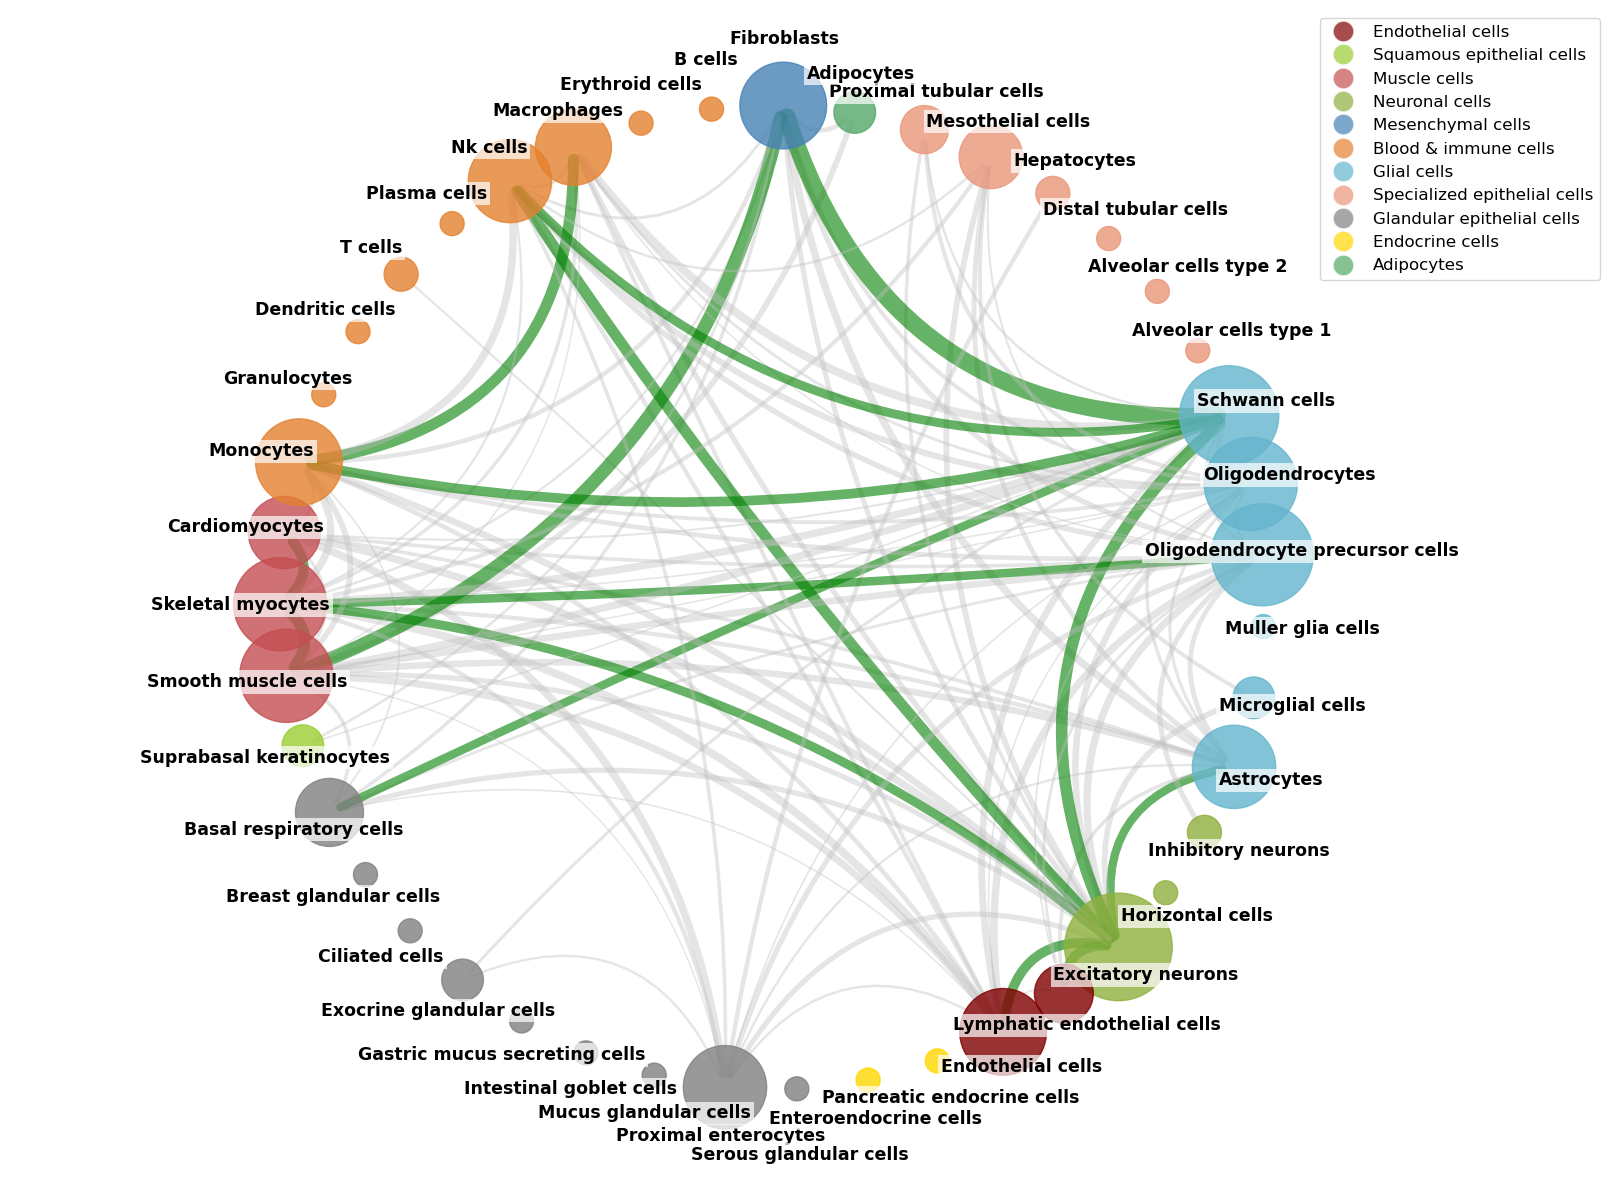


Correlation Values:
--------------------------------------------------
Node 1               Node 2               Correlation
--------------------------------------------------
Fibroblasts          Schwann cells        0.555 (Top)
Fibroblasts          Smooth muscle cells  0.504 (Top)
Excitatory neurons   Schwann cells        0.482 (Top)
Skeletal myocytes    Smooth muscle cells  0.479 (Top)
Excitatory neurons   Nk cells             0.475 (Top)
Macrophages          Monocytes            0.474 (Top)
Cardiomyocytes       Skeletal myocytes    0.463 (Top)
Excitatory neurons   Lymphatic endothelial cells 0.459 (Top)
Schwann cells        Monocytes            0.458 (Top)
Endothelial cells    Excitatory neurons   0.457 (Top)
Excitatory neurons   Skeletal myocytes    0.450 (Top)
Nk cells             Schwann cells        0.447 (Top)
Oligodendrocyte precursor cells Skeletal myocytes    0.443 (Top)
Basal respiratory cells Schwann cells        0.441 (Top)
Astrocytes           Excitatory neurons   0.44

In [32]:
G, pos = plot_correlation_network(
    correlation_matrix=correlation_matrix,
    filename = './Rev_results/corr_HC_no_thresholding',
    threshold=0.35,
    highlight_n=15,
    rotation_angle_adjust = 62,
    format_name=format_name,
    formatted_cell_categories=formatted_cell_categories,
    formatted_custom_colors=formatted_custom_colors,
    category_order=category_order,
    offset_label_position=offset_label_position
)